In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting

from dust_extinction.averages import CT06_MWGC

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from smart_plotters import cmd_plot 

In [2]:
def get_rc_sel_mask(cat):
    x = np.linspace(0, 2.5, 10)
    
    x0 = 0.52
    mask_x0_left = cat.color('f182m', 'f212n') > x0

    y0 = 14.8
    mask_above_y0 = cat.band('f182m') > y0
    mask_rc = mask_above_y0 & mask_x0_left

    pt1 = (0.5, 14.3)
    pt2 = (2.0, 20.)
    y1 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_below_y1 = cat.band('f182m') > ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_below_y1 & mask_rc

    pt1 = (0.5, 15.5)
    pt2 = (2.0, 20.9)
    y2 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_above_y2 = cat.band('f182m') < ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_rc & mask_above_y2

    return mask_rc

# Cloud C

In [3]:
cat_use = make_cat_use()
cat_use.catalog['Av'] = cat_use.get_Av('f182m', 'f212n')
cat_use.catalog['N(CO)'] = co_map.get_co_ice_column(cat_use, cat_use.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

In [4]:
cat_rc = JWSTCatalog(cat_use.catalog[get_rc_sel_mask(cat_use)])

In [5]:
fn = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f405n-merged_i2d.fits'
hdu = fits.open(fn)
ww = WCS(hdu['SCI'].header)
nanfield = np.nan * hdu['SCI'].data

In [6]:
reg_f = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_short.region')
reg_b = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudb.region')
reg_c1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc1_ice.reg')
reg_c2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc2_ice.reg')
reg_d = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudd_ice.reg')
reg_fil_r = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_right.region')
reg_left_cd = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/left_cloudd.region')
reg_c_n = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_north.region')
reg_c_s = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_south.region')

In [7]:
cat_f_rc = JWSTCatalog(cat_rc.table_region_mask(reg_f, ww))
cat_c1_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c1, ww))
cat_c2_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c2, ww))
cat_d_rc = JWSTCatalog(cat_rc.table_region_mask(reg_d, ww))
cat_b_rc = JWSTCatalog(cat_rc.table_region_mask(reg_b, ww))
cat_fil_r_rc = JWSTCatalog(cat_rc.table_region_mask(reg_fil_r, ww))
cat_left_cd_rc = JWSTCatalog(cat_rc.table_region_mask(reg_left_cd, ww))
cat_c_n_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_n, ww))
cat_c_s_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_s, ww))

# Brick

In [8]:
cat_brick = make_brick_cat()
cat_brick.catalog['Av'] = cat_brick.get_Av('f182m', 'f212n')
cat_brick.catalog['N(CO)'] = co_map.get_co_ice_column(cat_brick, cat_brick.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

Reading /orange/adamginsburg/jwst/brick/catalogs/basic_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits


In [9]:
cat_brick_rc = JWSTCatalog(cat_brick.catalog[get_rc_sel_mask(cat_brick)])

In [10]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')


In [11]:
fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
hdu_brick = fits.open(fn_brick)
ww_brick = WCS(hdu_brick['SCI'].header)
nanfield_brick = np.nan * hdu_brick['SCI'].data

In [12]:
cat_brick_north_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_punch_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nclear, ww_brick))
cat_brick_topc_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_topc, ww_brick))
cat_brick_sfrwide_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfrwide, ww_brick))

# Combined Figure

In [13]:
catalogs_rc = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc,
               cat_brick_sfr_rc, cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_topc_rc, cat_brick_sfrwide_rc]
labels = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
          'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff',
          'Brick Star-Forming Region', 'Brick Punch-Out', 'Brick South Foreground', 'Brick North Clear', 'Brick Top Center', 'Brick Star-Forming Wide']

In [14]:
len(catalogs_rc)

20

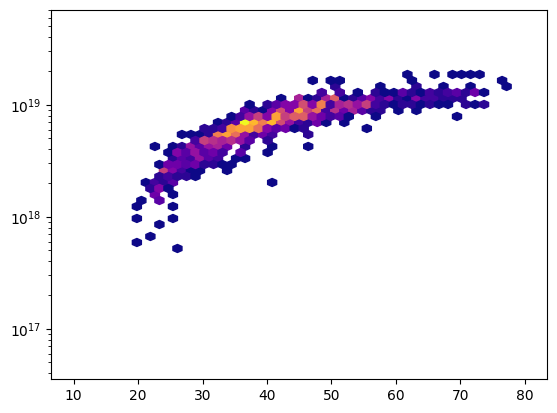

In [15]:
plt.hexbin(cat_f_rc.catalog['Av'], cat_f_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(5e16), np.log10(5e19)), yscale='log')

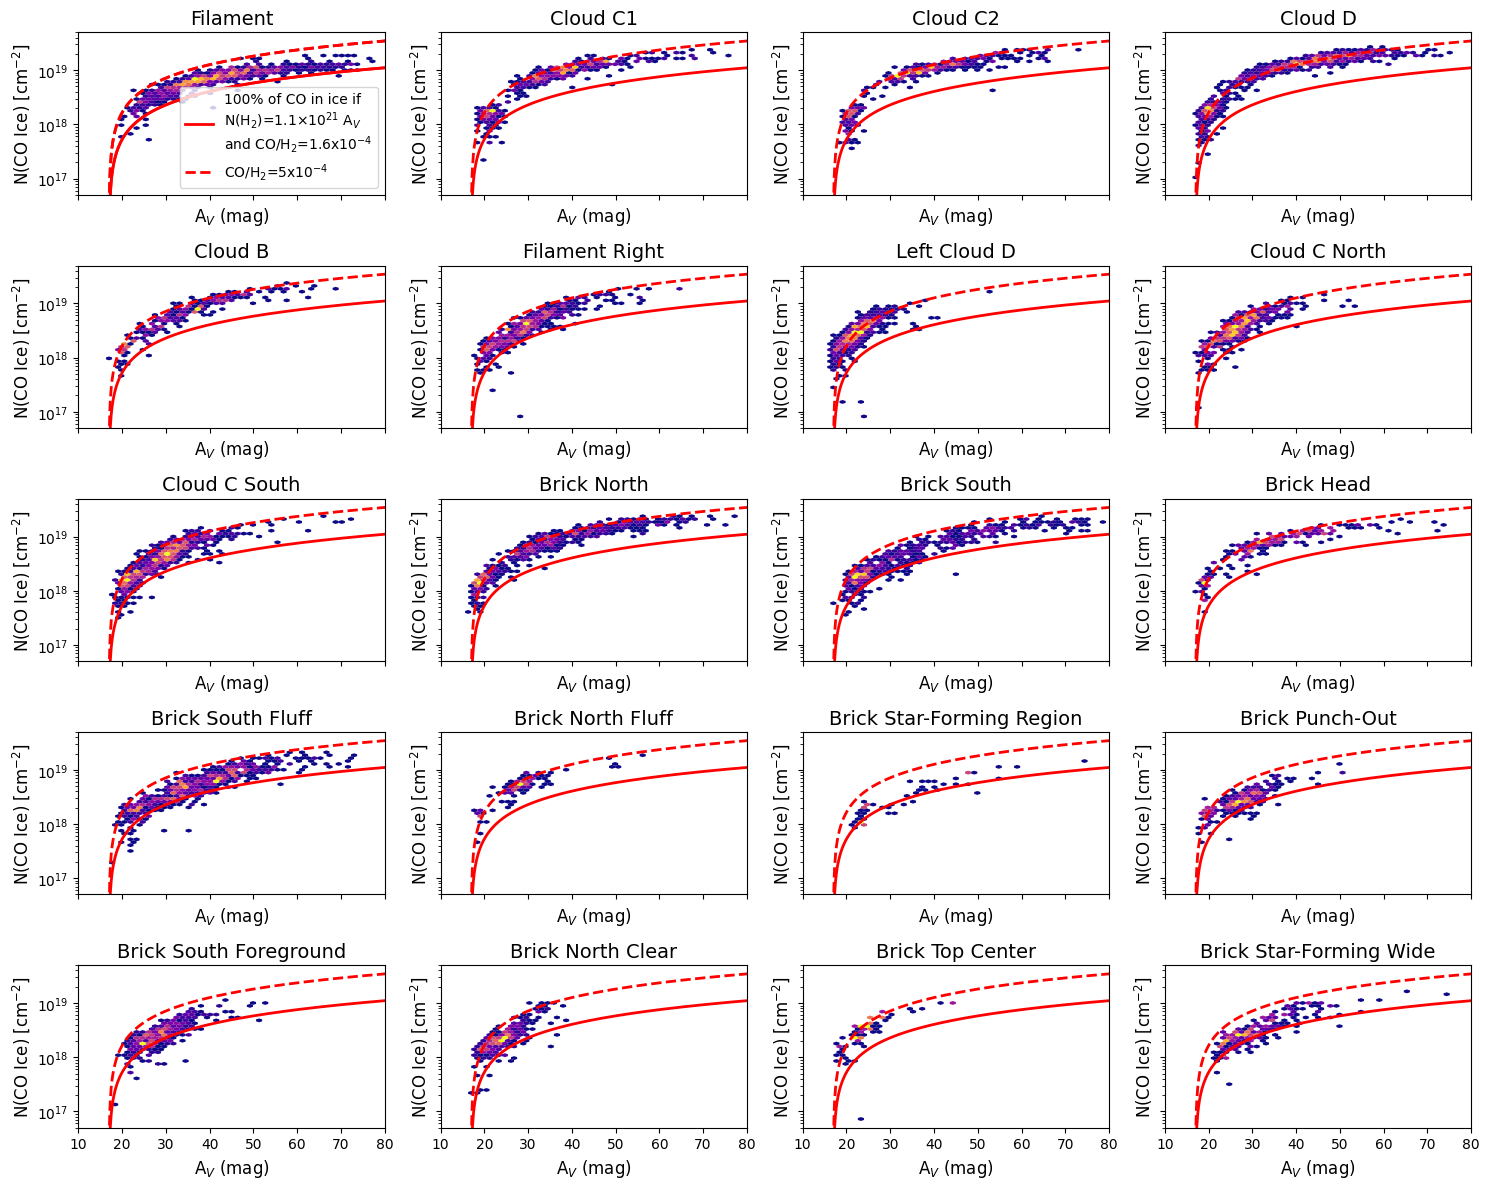

In [16]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharex=True, sharey=True)

Av_offset = 17
NCOofAV_alt1 = 1.1e21 * np.linspace(0.1, 100, 1000) * 5e-4
NCOofAV_alt3 = 1.1e21 * np.linspace(0.1, 100, 1000) * 1.6e-4

l1, = axes.flatten()[0].plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt3, linewidth=2, 
        label='100% of CO in ice if \nN(H$_2$)=1.1$\\times10^{21}$ A$_V$ \nand CO/H$_2$=1.6x10$^{-4}$', color='r', linestyle='-')
l3, = axes.flatten()[0].plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt1, linewidth=2, 
        label='CO/H$_2$=5x10$^{-4}$', color='r', linestyle='--')
axes.flatten()[0].legend()

for i in range(20):
    cat = catalogs_rc[i]
    ax = axes.flatten()[i]
    ax.hexbin(cat.catalog['Av'], cat.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(5e16), np.log10(5e19)), yscale='log', edgecolors='none')
    ax.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt3, linewidth=2, color='r', linestyle='-')
    ax.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt1, linewidth=2, color='r', linestyle='--')
    ax.set_xlabel('A$_V$ (mag)', fontsize=12)
    ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=12)
    ax.set_xlim(10, 80)
    ax.set_ylim(5e16, 5e19)
    ax.set_yscale('log')
    ax.set_title(labels[i], fontsize=14)

plt.tight_layout()

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_vs_Av.png', dpi=300, bbox_inches='tight')
plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_vs_Av.pdf', bbox_inches='tight')